# OLS Modeling

기존 `Modeling_OLS.ipynb`를 기준으로 아래 흐름으로 정리한 버전.

**수정 포인트**
1. `directional_accuracy()`에서 예측값 0은 방향 판단 제외
2. `naive_zero`, `naive_lag1` 기준모델 추가
3. 시간순 train/test split 추가 → 표본 밖 성능 확인
4. OLS는 `statsmodels`로 적합 → 계수, p-value, HC3 robust SE 확인
5. 잔차 진단: Durbin-Watson, Ljung-Box, Breusch-Pagan
6. AIC backward는 train 데이터에서만 수행 → test 성능 비교 가능
7. 하드코딩된 변수 수/결론 제거 → 결과가 바뀌어도 자동 반영


In [1]:
# =========================
# 0. 기본 설정
# =========================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

TARGET = "oil_diff_target"
TEST_SIZE = 0.2
DATA_FILE_NAME = "dataset4_derived_full_with_dummies.csv"


def find_data_path(filename=DATA_FILE_NAME):
    cwd = Path.cwd().resolve()

    candidates = []
    for base in [cwd, *cwd.parents]:
        candidates.extend([
            base / "data" / "Finance_Final" / filename,
            base.parent / "data" / "Finance_Final" / filename,
            base / "Finance_Final" / filename,
            base / filename,
        ])

    for p in candidates:
        if p.exists():
            return p

    for base in [cwd, *cwd.parents]:
        matches = list(base.rglob(filename))
        matches = [p for p in matches if ".git" not in p.parts]
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"{filename} 파일을 찾지 못했습니다.\n"
        f"현재 실행 위치: {cwd}\n"
        "노트북을 repo root나 src 폴더에서 실행하거나, 데이터 경로를 직접 지정하세요."
    )


DATA_PATH = find_data_path()
print("현재 실행 위치:", Path.cwd().resolve())
print("찾은 데이터 경로:", DATA_PATH)


현재 실행 위치: C:\Users\이은서\Desktop\비어플\Final_File\BAF_Finance2\src
찾은 데이터 경로: C:\Users\이은서\Desktop\비어플\Final_File\BAF_Finance2\data\Finance_Final\dataset4_derived_full_with_dummies.csv


In [2]:
# =========================
# 1. 데이터 불러오기
# =========================

cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()

if "date" in cols:
    DATE_COL = "date"
elif "Date" in cols:
    DATE_COL = "Date"
elif "DATE" in cols:
    DATE_COL = "DATE"
else:
    DATE_COL = cols[0]
    print(f"date 컬럼명이 명확하지 않아서 첫 번째 컬럼을 날짜로 사용합니다: {DATE_COL}")

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.rename(columns={DATE_COL: "date"}).set_index("date").sort_index()

print("shape:", df.shape)
print("기간:", df.index.min().date(), "~", df.index.max().date())
print("컬럼 수:", len(df.columns))
display(df.head())


shape: (4548, 43)
기간: 2008-01-31 ~ 2026-03-16
컬럼 수: 43


,oil_diff_target,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TreasuryYield,FedFundsRate,oil_diff_lag1,oil_diff_lag5,oil_volatility_5,oil_volatility_20,MA_5,MA_20,MA_ratio,MA_5_gt_MA_20,oil_momentum_5,oil_momentum_20,TermSpread_inversion,vix_high,is_monday,is_friday,gfc_2008_shock,gfc_2008_regime,opec_2014_shock,opec_2014_regime,covid_2020_shock,covid_2020_regime,war_2022_shock,war_2022_regime,gfc_2008_window,opec_2014_window,covid_2020_window,war_2022_window,cond_vix_gt_30,cond_termspread_inv,cond_inventory_draw,cond_opec_cut
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2008-01-31,-2.64,-0.67,-0.162867,1.644,-0.0895,-1.42,0.5431,23.6,2297.0,-419.744,29.0,-0.11,-0.27,0.68,2.33,0.575647,1.359676,91.406,92.6370,0.986712,0,1.69,-7.97,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2008-02-01,1.04,-2.64,-0.439278,0.611,-0.1723,-2.18,0.0357,-7.1,3555.0,284.497,-44.0,-0.05,-0.25,-0.67,0.39,1.445258,1.449309,91.138,92.1300,0.989233,0,-1.34,-10.14,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-02-04,-1.75,1.04,-0.439278,0.611,-0.0036,1.97,0.0357,-7.1,3555.0,284.497,-44.0,0.06,-0.25,-2.64,0.62,1.520043,1.477082,90.954,91.7385,0.991449,0,-0.92,-7.83,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-02-05,-1.16,-1.75,-0.439278,0.611,0.5972,2.25,0.0357,-7.1,3555.0,284.497,-44.0,-0.07,-0.25,1.04,0.67,1.564759,1.401960,90.286,91.4005,0.987806,0,-3.34,-6.76,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-02-06,0.91,-1.16,-0.439278,0.611,-0.0773,0.73,0.0357,-7.1,3555.0,284.497,-44.0,0.00,-0.25,-1.75,0.68,1.373110,1.354440,89.250,90.9370,0.981449,0,-5.18,-9.27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# =========================
# 2. 결측 확인 및 제거
# =========================

print("결측 합계 (0 아닌 것만):")
na = df.isna().sum()
display(na[na > 0].sort_values(ascending=False).to_frame("NA_count"))

df_model = df.dropna().copy()

print(f"원본 {len(df)}행 → 결측 제거 후 {len(df_model)}행")
print(f"제거된 행 수: {len(df) - len(df_model)}")
print("모델링 기간:", df_model.index.min().date(), "~", df_model.index.max().date())

if TARGET not in df_model.columns:
    raise ValueError(f"TARGET 컬럼이 없습니다: {TARGET}")


결측 합계 (0 아닌 것만):


,NA_count
oil_diff_target,1


원본 4548행 → 결측 제거 후 4547행
제거된 행 수: 1
모델링 기간: 2008-01-31 ~ 2026-03-13


In [4]:
# =========================
# 3. 시간순 train/test split
# =========================

split_idx = int(len(df_model) * (1 - TEST_SIZE))

df_train = df_model.iloc[:split_idx].copy()
df_test  = df_model.iloc[split_idx:].copy()

print("train:", df_train.index.min().date(), "~", df_train.index.max().date(), "| n =", len(df_train))
print("test :", df_test.index.min().date(),  "~", df_test.index.max().date(),  "| n =", len(df_test))


train: 2008-01-31 ~ 2022-07-19 | n = 3637
test : 2022-07-20 ~ 2026-03-13 | n = 910


## 4. 설명변수 정리

- 0/1 더미는 정상성 검정 대상에서 제외
- 연속형 변수는 train 데이터 기준으로 ADF + KPSS 검정
- 완전 중복 변수는 train 데이터 기준으로 제거
- 이 과정은 test 성능 평가 전에 수행하므로, 최소한의 누수 방지 목적이 있음


In [5]:
# =========================
# 4-1. 변수 타입 구분
# =========================

candidate_cols = [c for c in df_model.columns if c != TARGET]

# train 기준으로 0/1 또는 고유값 2개 이하이면 binary/dummy로 간주
binary_cols = [c for c in candidate_cols if df_train[c].nunique(dropna=True) <= 2]
cont_cols = [c for c in candidate_cols if c not in binary_cols]

print(f"연속형 변수 ({len(cont_cols)}개):")
print(cont_cols)

print(f"\n0/1 더미 또는 이산형 변수 ({len(binary_cols)}개, 정상성 검정 제외):")
print(binary_cols)


연속형 변수 (21개):
['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'oil_momentum_5', 'oil_momentum_20']

0/1 더미 또는 이산형 변수 (21개, 정상성 검정 제외):
['MA_5_gt_MA_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_vix_gt_30', 'cond_termspread_inv', 'cond_inventory_draw', 'cond_opec_cut']


In [6]:
# =========================
# 4-2. ADF + KPSS 정상성 검정
# =========================

def stationarity_row(s):
    s = pd.Series(s).dropna()

    if len(s) < 30:
        return np.nan, False, np.nan, False, "판단보류"

    # ADF: H0 = 단위근 존재, p < 0.05면 정상으로 판단
    try:
        adf_p = adfuller(s, autolag="AIC")[1]
    except Exception:
        adf_p = np.nan

    # KPSS: H0 = 정상, p >= 0.05면 정상으로 판단
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            kpss_p = kpss(s, regression="c", nlags="auto")[1]
        except Exception:
            kpss_p = np.nan

    adf_stationary = (not np.isnan(adf_p)) and (adf_p < 0.05)
    kpss_stationary = (not np.isnan(kpss_p)) and (kpss_p >= 0.05)

    if adf_stationary and kpss_stationary:
        verdict = "정상"
    elif (not adf_stationary) and (not kpss_stationary):
        verdict = "비정상"
    else:
        verdict = "판단보류"

    return adf_p, adf_stationary, kpss_p, kpss_stationary, verdict


rows = []
for c in [TARGET] + cont_cols:
    adf_p, adf_stat, kpss_p, kpss_stat, verdict = stationarity_row(df_train[c])
    rows.append({
        "variable": c,
        "ADF_p": adf_p,
        "ADF_정상": adf_stat,
        "KPSS_p": kpss_p,
        "KPSS_정상": kpss_stat,
        "판정": verdict,
        "is_target": c == TARGET,
    })

stat_df = pd.DataFrame(rows)

stat_show = stat_df.copy()
stat_show["ADF_p"] = stat_show["ADF_p"].map(lambda x: f"{x:.4g}" if pd.notna(x) else "NA")
stat_show["KPSS_p"] = stat_show["KPSS_p"].map(lambda x: f"{x:.4g}" if pd.notna(x) else "NA")

print("===== 정상성 검정 결과: train 기준 =====")
display(stat_show.drop(columns="is_target"))

print("판정 분포:")
display(stat_df.loc[~stat_df["is_target"], "판정"].value_counts().to_frame("count"))


===== 정상성 검정 결과: train 기준 =====


,variable,ADF_p,ADF_정상,KPSS_p,KPSS_정상,판정
0,oil_diff_target,2.298e-16,True,0.1,True,정상
1,OilPrice,2.172e-16,True,0.1,True,정상
2,RealInterestRate,1.471e-13,True,0.1,True,정상
3,CPI,1.456e-06,True,0.01,False,판단보류
4,DollarIndex,2.537e-28,True,0.1,True,정상
5,VIX,0,True,0.1,True,정상
6,IndustryProduction,1.173e-12,True,0.1,True,정상
7,CPE,6.968e-15,True,0.1,True,정상
8,OilInventories,8.58e-17,True,0.1,True,정상
9,OPECProduction,1.286e-13,True,0.1,True,정상


판정 분포:


,count
판정,
정상,15
판단보류,5
비정상,1


In [7]:
# =========================
# 4-3. 완전 중복 변수 제거
# =========================

dup_groups = []
for c in candidate_cols:
    found = False
    for grp in dup_groups:
        if df_train[c].equals(df_train[grp[0]]):
            grp.append(c)
            found = True
            break
    if not found:
        dup_groups.append([c])

dup_groups = [g for g in dup_groups if len(g) > 1]

drop_dup = []
if dup_groups:
    print("완전 동일 값 변수 그룹:")
    for g in dup_groups:
        print(f"  {g}  → 유지: {g[0]} / 제거: {g[1:]}")
        drop_dup.extend(g[1:])
else:
    print("완전 중복 변수 없음.")

print("\n중복으로 제거할 변수:", drop_dup)


완전 동일 값 변수 그룹:
  ['TermSpread_inversion', 'cond_termspread_inv']  → 유지: TermSpread_inversion / 제거: ['cond_termspread_inv']
  ['vix_high', 'cond_vix_gt_30']  → 유지: vix_high / 제거: ['cond_vix_gt_30']

중복으로 제거할 변수: ['cond_termspread_inv', 'cond_vix_gt_30']


In [8]:
# =========================
# 4-4. 최종 설명변수 확정
# =========================

# 연속형 변수 중 정상 아닌 변수 제외
nonstat_cols = stat_df.loc[
    (~stat_df["is_target"]) & (stat_df["판정"] != "정상"),
    "variable"
].tolist()

exclude = sorted(set(nonstat_cols) | set(drop_dup))
feature_cols = [c for c in candidate_cols if c not in exclude]

print("=== 제외된 변수 ===")
if exclude:
    for c in exclude:
        reasons = []
        if c in nonstat_cols:
            v = stat_df.loc[stat_df["variable"] == c, "판정"].iloc[0]
            reasons.append(f"정상성 {v}")
        if c in drop_dup:
            reasons.append("완전 중복")
        print(f"- {c:28s} ({', '.join(reasons)})")
else:
    print("(없음)")

print(f"\n최종 설명변수 {len(feature_cols)}개:")
print(feature_cols)

X_train = sm.add_constant(df_train[feature_cols], has_constant="add")
y_train = df_train[TARGET]

X_test = sm.add_constant(df_test[feature_cols], has_constant="add")
y_test = df_test[TARGET]

print("\nX_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)


=== 제외된 변수 ===
- CPI                          (정상성 판단보류)
- FedFundsRate                 (정상성 판단보류)
- MA_20                        (정상성 판단보류)
- MA_5                         (정상성 비정상)
- cond_termspread_inv          (완전 중복)
- cond_vix_gt_30               (완전 중복)
- oil_volatility_20            (정상성 판단보류)
- oil_volatility_5             (정상성 판단보류)

최종 설명변수 34개:
['OilPrice', 'RealInterestRate', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'oil_diff_lag1', 'oil_diff_lag5', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_inventory_draw', 'cond_opec_cut']

X_train: (3637, 35) | y_train: (3637,)
X_test : (910

## 5. 평가 함수

`naive_zero`처럼 예측값이 전부 0인 모델은 방향을 예측했다고 보기 어렵기 때문에 `Directional_Accuracy`에서 0 예측값은 제외한다.


In [9]:
# =========================
# 5. 성능 평가 함수
# =========================
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # 예측값이 0이면 방향 판단에서 제외
    mask = y_pred != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask]))


def adjusted_r2_score(y_true, y_pred, n_vars):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)

    if n_vars is None or n <= n_vars + 1:
        return np.nan

    return 1 - (1 - r2) * (n - 1) / (n - n_vars - 1)


def regression_metrics(y_true, y_pred, n_vars=None):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": adjusted_r2_score(y_true, y_pred, n_vars),
        "DirAcc": directional_accuracy(y_true, y_pred)
    }


def model_compare_row(model_name, y_true, y_pred, n_vars=None):
    out = {
        "model": model_name
    }

    if n_vars is not None:
        out["n_vars"] = n_vars

    out.update(regression_metrics(y_true, y_pred, n_vars=n_vars))
    return out


## 6. Full OLS 적합

- `ols_full`: 일반 OLS (등분산 가정)
- 표준오차/p-value는 잠정적이며, **§8 잔차 진단에서 이분산이 확인되면 §8 끝에서 HC3 robust SE로 보정**한다.


In [10]:
# =========================
# 6. Full OLS 적합 (일반 SE)
# =========================
# 이 단계에서는 일반 OLS만 적합한다.
# 이분산성/자기상관 여부는 §8 잔차 진단에서 확인한 뒤,
# 그 결과에 따라 HC3(또는 HAC) robust SE를 채택한다.

ols_full = sm.OLS(y_train, X_train).fit()

print("===== Full OLS: non-robust SE (잠정) =====")
print(ols_full.summary())


===== Full OLS: non-robust SE (잠정) =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     6.438
Date:                Thu, 21 May 2026   Prob (F-statistic):           7.14e-28
Time:                        00:22:55   Log-Likelihood:                -7784.7
No. Observations:                3637   AIC:                         1.564e+04
Df Residuals:                    3602   BIC:                         1.586e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [11]:
# =========================
# 6-1. 핵심 지표 요약
# =========================

dw_full = durbin_watson(ols_full.resid)

summary_full = pd.DataFrame([{
    "model": "Full OLS",
    "n_obs": int(ols_full.nobs),
    "n_vars": len(feature_cols),
    "R2_train": ols_full.rsquared,
    "Adj_R2_train": ols_full.rsquared_adj,
    "AIC": ols_full.aic,
    "BIC": ols_full.bic,
    "F_pvalue": ols_full.f_pvalue,
    "Durbin_Watson": dw_full,
}])

display(summary_full.round(4))


,model,n_obs,n_vars,R2_train,Adj_R2_train,AIC,BIC,F_pvalue,Durbin_Watson
0,Full OLS,3637,34,0.0573,0.0484,15639.4476,15856.4096,0.0,1.9934


## 7. VIF 점검

일반 기준:
- VIF > 10: 심각한 다중공선성
- VIF > 5: 주의


In [12]:
# =========================
# 7. VIF 계산
# =========================

def compute_vif(X):
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        try:
            vif = variance_inflation_factor(X.values, i)
        except Exception:
            vif = np.inf
        rows.append({"variable": col, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df = compute_vif(X_train)

print("VIF > 10:", (vif_df["VIF"] > 10).sum(), "개")
print("VIF > 5 :", (vif_df["VIF"] > 5).sum(), "개")
display(vif_df)


VIF > 10: 0 개
VIF > 5 : 1 개


,variable,VIF
0,CPE,5.773086
1,IndustryProduction,3.781066
2,oil_momentum_20,3.417859
3,MA_ratio,2.974747
4,OPECProduction,2.884251
5,covid_2020_shock,2.408779
6,oil_momentum_5,2.331406
7,OilInventories,2.319072
8,cond_inventory_draw,2.175615
9,MA_5_gt_MA_20,2.170877


## 8. 잔차 진단

확인할 것:
1. 자기상관: ACF/PACF, Ljung-Box, Durbin-Watson
2. 이분산성: Breusch-Pagan

**이 단계의 결과에 따라 §8-5에서 robust SE(HC3) 채택 여부를 결정**한다.
- 이분산만 → HC3
- 자기상관까지 → HAC(Newey-West) 권장
- 둘 다 없음 → 일반 SE 유지


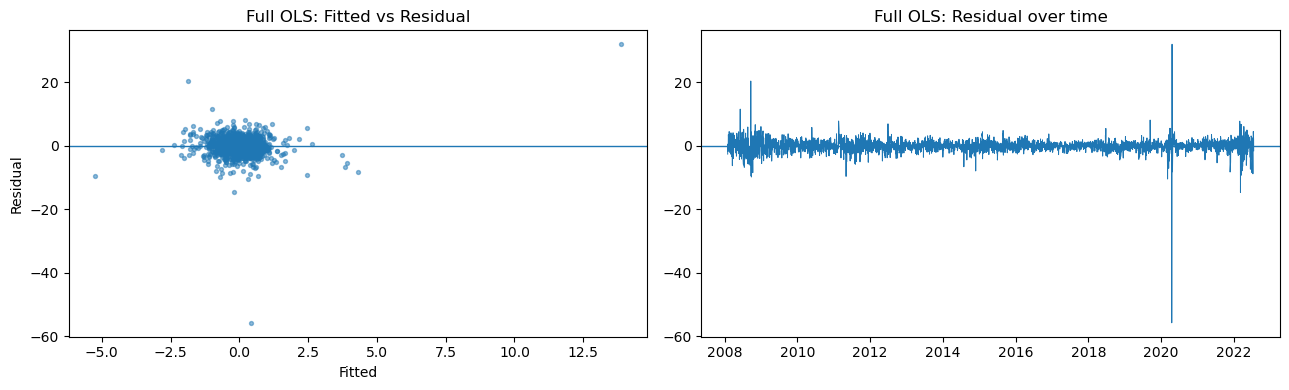

In [13]:
# =========================
# 8-1. 잔차 시각화
# =========================

resid_full = ols_full.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(ols_full.fittedvalues, resid_full, s=8, alpha=0.5)
axes[0].axhline(0, lw=1)
axes[0].set_xlabel("Fitted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Full OLS: Fitted vs Residual")

axes[1].plot(resid_full.index, resid_full, lw=0.7)
axes[1].axhline(0, lw=1)
axes[1].set_title("Full OLS: Residual over time")

plt.tight_layout()
plt.show()


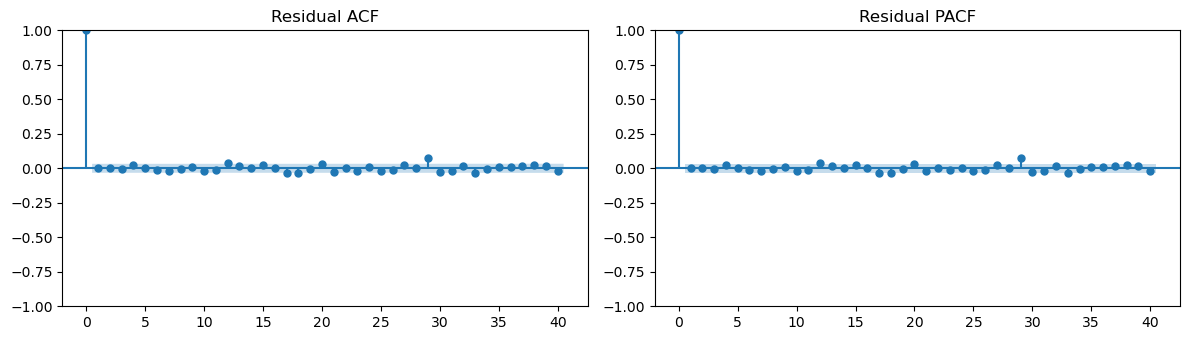

In [14]:
# =========================
# 8-2. ACF / PACF
# =========================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

plot_acf(resid_full, lags=40, ax=axes[0])
axes[0].set_title("Residual ACF")

plot_pacf(resid_full, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Residual PACF")

plt.tight_layout()
plt.show()


In [15]:
# =========================
# 8-3. 잔차 진단 함수
# =========================

def residual_diagnostics(model, X_for_bp, lags=[5, 10, 20], name="model"):
    resid = model.resid

    dw = durbin_watson(resid)
    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X_for_bp)

    out = {
        "model": name,
        "Durbin_Watson": dw,
        "LB_min_p": lb["lb_pvalue"].min(),
        "BP_LM_p": bp_p,
        "BP_F_p": bp_fp,
        "autocorr_judgement": "Bad: 자기상관 의심" if lb["lb_pvalue"].min() < 0.05 else "Good: 자기상관 없음",
        "hetero_judgement": "Bad: 이분산 있음" if bp_p < 0.05 else "Good: 등분산",
    }

    print(f"===== {name} 잔차 진단 =====")
    display(pd.DataFrame([out]).round(5))

    print("Ljung-Box 상세:")
    display(lb.round(5))

    return out, lb

diag_full, lb_full = residual_diagnostics(ols_full, X_train, name="Full OLS")


===== Full OLS 잔차 진단 =====


,model,Durbin_Watson,LB_min_p,BP_LM_p,BP_F_p,autocorr_judgement,hetero_judgement
0,Full OLS,1.99337,0.19286,0.0,0.0,Good: 자기상관 없음,Bad: 이분산 있음


Ljung-Box 상세:


,lb_stat,lb_pvalue
5,2.17878,0.82390
10,5.61608,0.84642
20,25.22753,0.19286


### 8-4. 잔차 진단 결과에 따른 SE 선택

위 진단을 종합:
- **Breusch-Pagan p < 0.05** → 이분산 존재 → HC3 채택
- **Ljung-Box p ≥ 0.05** (자기상관 없음) → HAC(Newey-West)까지 갈 필요 없음
- 둘 다 무의미하다면 일반 SE를 그대로 사용

아래 셀에서 진단 결과를 보고 HC3 채택 여부를 자동 판단한 뒤,
이후 모든 보고/해석은 `ols_full_hc3` 기준으로 통일한다.

In [16]:
# =========================
# 8-5. 진단 기반 robust SE 채택
# =========================
bp_p_full = float(diag_full["BP_LM_p"])
lb_min_p_full = float(diag_full["LB_min_p"])

use_hc3 = bp_p_full < 0.05
use_hac = lb_min_p_full < 0.05  # 자기상관까지 있으면 HAC 권장

print(f"BP p-value      : {bp_p_full:.5f}  → 이분산 {'있음' if use_hc3 else '없음'}")
print(f"LB min p-value  : {lb_min_p_full:.5f}  → 자기상관 {'있음' if use_hac else '없음'}")

if use_hac:
    print("\n→ 자기상관까지 있으므로 HAC(Newey-West) 사용을 권장.")
    print("  현재는 코드 단순화를 위해 HC3로 적합하지만, 보고시 HAC 보강 필요.")
elif use_hc3:
    print("\n→ 이분산만 존재. HC3 robust SE 채택.")
else:
    print("\n→ 이분산/자기상관 모두 무의미. 일반 SE를 그대로 사용해도 됨.")
    print("  비교 목적으로 HC3도 함께 적합.")

# 채택된 robust SE로 재적합 (점추정 동일, SE/p-value만 다름)
ols_full_hc3 = sm.OLS(y_train, X_train).fit(cov_type="HC3")

print("\n===== Full OLS: HC3 robust SE =====")
print(ols_full_hc3.summary())


BP p-value      : 0.00000  → 이분산 있음
LB min p-value  : 0.19286  → 자기상관 없음

→ 이분산만 존재. HC3 robust SE 채택.

===== Full OLS: HC3 robust SE =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                    0.9661
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.524
Time:                        00:22:55   Log-Likelihood:                -7784.7
No. Observations:                3637   AIC:                         1.564e+04
Df Residuals:                    3602   BIC:                         1.586e+04
Df Model:                          34                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      

In [17]:
# =========================
# 8-6. 유의 변수 비교: nonrobust vs HC3
# =========================
# HC3 채택 후 어느 변수의 유의성이 달라지는지 확인.

coef_cmp = pd.DataFrame({
    "coef": ols_full.params,
    "SE_nonrobust": ols_full.bse,
    "p_nonrobust": ols_full.pvalues,
    "SE_HC3": ols_full_hc3.bse,
    "p_HC3": ols_full_hc3.pvalues,
}).drop(index="const", errors="ignore")

coef_cmp["SE_ratio_HC3/non"] = coef_cmp["SE_HC3"] / coef_cmp["SE_nonrobust"]

def sig_tag(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

coef_cmp["sig_non"] = coef_cmp["p_nonrobust"].map(sig_tag)
coef_cmp["sig_HC3"] = coef_cmp["p_HC3"].map(sig_tag)
coef_cmp["변경"] = np.where(coef_cmp["sig_non"] != coef_cmp["sig_HC3"], "변경", "")

display(
    coef_cmp
    .sort_values(["변경", "p_HC3"], ascending=[False, True])
    .round(5)
)

sig_hc3 = coef_cmp[coef_cmp["p_HC3"] < 0.05].sort_values("p_HC3")
print(f"HC3 기준 5% 유의 변수: {len(sig_hc3)}개")
display(sig_hc3[["coef", "SE_HC3", "p_HC3", "sig_HC3"]].round(5))


,coef,SE_nonrobust,p_nonrobust,SE_HC3,p_HC3,SE_ratio_HC3/non,sig_non,sig_HC3,변경
gfc_2008_regime,0.62825,0.24212,0.00950,0.30523,0.03956,1.26063,***,**,변경
VIX,-0.04331,0.01819,0.01734,0.02252,0.05447,1.23786,**,*,변경
RealInterestRate,-0.32772,0.19949,0.10051,0.18533,0.07700,0.92901,,*,변경
CPE,-0.00146,0.00047,0.00207,0.00083,0.07817,1.75029,***,*,변경
IndustryProduction,0.09631,0.04825,0.04601,0.05522,0.08115,1.14443,**,*,변경
MA_5_gt_MA_20,0.41616,0.10189,0.00005,0.24485,0.08920,2.40318,***,*,변경
war_2022_window,2.30038,0.63563,0.00030,1.61879,0.15530,2.54675,***,,변경
gfc_2008_shock,-0.74103,0.34060,0.02964,0.56708,0.19130,1.66496,**,,변경
OPECProduction,-0.00015,0.00009,0.08610,0.00012,0.19397,1.32171,*,,변경
vix_high,-0.29802,0.15821,0.05969,0.23160,0.19816,1.46382,*,,변경


HC3 기준 5% 유의 변수: 1개


,coef,SE_HC3,p_HC3,sig_HC3
gfc_2008_regime,0.62825,0.30523,0.03956,**


## 9. AIC Backward Stepwise

기존 p-value 기준 stepwise는 변수를 과도하게 제거할 수 있어서, 최종 모델 후보는 **AIC backward**를 우선 사용한다.

주의: AIC는 likelihood 기반이라 HC3 robust SE와 직접 연결되는 기준은 아니다.  
그래도 변수 선택은 AIC로 하고, 최종 해석은 HC3 표준오차로 보는 방식이 실무적으로 깔끔하다.


In [18]:
# =========================
# 9. AIC Backward Stepwise
# =========================

def fit_ols_by_features(features, robust=False):
    X_cur = sm.add_constant(df_train[features], has_constant="add")
    if robust:
        return sm.OLS(y_train, X_cur).fit(cov_type="HC3")
    return sm.OLS(y_train, X_cur).fit()


def aic_backward(initial_features):
    current = list(initial_features)
    history = []

    m_current = fit_ols_by_features(current, robust=False)
    current_aic = m_current.aic

    history.append({
        "step": 0,
        "n_vars": len(current),
        "removed": "(시작)",
        "AIC": current_aic,
        "BIC": m_current.bic,
        "R2": m_current.rsquared,
        "Adj_R2": m_current.rsquared_adj,
        "delta_AIC": 0.0,
    })

    step = 0

    while len(current) > 1:
        trials = []

        for v in current:
            trial_features = [c for c in current if c != v]
            m_trial = fit_ols_by_features(trial_features, robust=False)
            trials.append({
                "drop_var": v,
                "AIC": m_trial.aic,
                "BIC": m_trial.bic,
                "R2": m_trial.rsquared,
                "Adj_R2": m_trial.rsquared_adj,
                "delta_AIC": m_trial.aic - current_aic,
            })

        trial_df = pd.DataFrame(trials).sort_values("AIC")
        best = trial_df.iloc[0]

        # 어떤 변수를 제거해도 AIC가 줄지 않으면 종료
        if best["delta_AIC"] >= 0:
            break

        removed = best["drop_var"]
        current.remove(removed)
        current_aic = best["AIC"]
        step += 1

        history.append({
            "step": step,
            "n_vars": len(current),
            "removed": removed,
            "AIC": best["AIC"],
            "BIC": best["BIC"],
            "R2": best["R2"],
            "Adj_R2": best["Adj_R2"],
            "delta_AIC": best["delta_AIC"],
        })

    return current, pd.DataFrame(history)


final_aic_features, hist_aic_df = aic_backward(feature_cols)

print(f"AIC backward 종료: 최종 변수 {len(final_aic_features)}개")
display(hist_aic_df.round(5))

print("최종 변수:")
for c in final_aic_features:
    print("+", c)


AIC backward 종료: 최종 변수 19개


,step,n_vars,removed,AIC,BIC,R2,Adj_R2,delta_AIC
0,0,34,(시작),15639.44755,15856.40956,0.05729,0.04839,0.00000
1,1,33,gfc_2008_window,15637.46993,15848.23303,0.05728,0.04865,-1.97762
2,2,32,is_monday,15635.49329,15840.05747,0.05728,0.04891,-1.97664
3,3,31,opec_2014_regime,15633.52915,15831.89442,0.05727,0.04916,-1.96414
4,4,30,OilProduction,15631.56273,15823.72908,0.05726,0.04942,-1.96642
5,5,29,war_2022_regime,15629.62689,15815.59432,0.05724,0.04966,-1.93584
6,6,28,DollarIndex,15627.83757,15807.60609,0.05719,0.04987,-1.78932
7,7,27,oil_momentum_5,15626.17157,15799.74118,0.05710,0.05005,-1.66600
8,8,26,oil_momentum_20,15624.51775,15791.88844,0.05701,0.05022,-1.65382
9,9,25,cond_inventory_draw,15623.01982,15784.19160,0.05688,0.05035,-1.49793


최종 변수:
+ OilPrice
+ RealInterestRate
+ VIX
+ IndustryProduction
+ CPE
+ OilInventories
+ OPECProduction
+ TreasuryYield
+ oil_diff_lag1
+ MA_ratio
+ MA_5_gt_MA_20
+ vix_high
+ is_friday
+ gfc_2008_shock
+ gfc_2008_regime
+ opec_2014_window
+ covid_2020_window
+ war_2022_window
+ cond_opec_cut


In [19]:
# =========================
# 9-1. AIC 최종 모델 적합
# =========================

X_aic_train = sm.add_constant(df_train[final_aic_features], has_constant="add")
X_aic_test  = sm.add_constant(df_test[final_aic_features], has_constant="add")

ols_aic = sm.OLS(y_train, X_aic_train).fit()
ols_aic_hc3 = sm.OLS(y_train, X_aic_train).fit(cov_type="HC3")

print("===== AIC selected OLS: HC3 robust SE =====")
print(ols_aic_hc3.summary())


===== AIC selected OLS: HC3 robust SE =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1.494
Date:                Thu, 21 May 2026   Prob (F-statistic):             0.0771
Time:                        00:22:58   Log-Likelihood:                -7788.8
No. Observations:                3637   AIC:                         1.562e+04
Df Residuals:                    3617   BIC:                         1.574e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [20]:
# =========================
# 9-2. AIC 모델 잔차 진단
# =========================

diag_aic, lb_aic = residual_diagnostics(ols_aic, X_aic_train, name="AIC OLS")


===== AIC OLS 잔차 진단 =====


,model,Durbin_Watson,LB_min_p,BP_LM_p,BP_F_p,autocorr_judgement,hetero_judgement
0,AIC OLS,1.99513,0.17075,0.0,0.0,Good: 자기상관 없음,Bad: 이분산 있음


Ljung-Box 상세:


,lb_stat,lb_pvalue
5,1.81844,0.87365
10,4.56398,0.91834
20,25.85213,0.17075


## 10. 표본 밖 성능 비교

비교 모델:
- `naive_zero`: 항상 0 예측
- `naive_lag1`: 직전 타깃값으로 예측
- `Full OLS`
- `AIC OLS`


In [21]:
# =========================
# 10. Test 성능 비교
# =========================

# 기준모델 1: 항상 0
pred_naive_zero = np.zeros(len(y_test))

# 기준모델 2: 직전 oil_diff_target
# 첫 test 시점의 lag1도 df_model 전체에서 shift해서 가져오므로 직전 train 마지막 값 사용 가능
pred_naive_lag1 = df_model[TARGET].shift(1).loc[y_test.index].fillna(0).values

# OLS 예측
pred_full = ols_full.predict(X_test)
pred_aic = ols_aic.predict(X_aic_test)

compare_test = pd.DataFrame([
    model_compare_row("naive_zero", y_test, pred_naive_zero, n_vars=0),
    model_compare_row("naive_lag1", y_test, pred_naive_lag1, n_vars=1),
    model_compare_row("Full OLS", y_test, pred_full, n_vars=len(feature_cols)),
    model_compare_row("AIC OLS", y_test, pred_aic, n_vars=len(final_aic_features)),
])

display(compare_test.round(5).sort_values("RMSE"))

print("참고: naive_zero는 예측값이 전부 0이라 DirAcc를 NaN으로 처리함.")


,model,n_vars,MAE,RMSE,R2,Adj_R2,DirAcc
0,naive_zero,0,1.25826,1.70028,-0.00005,-0.00005,NaN
3,AIC OLS,19,1.29644,1.75830,-0.06946,-0.09229,0.49560
2,Full OLS,34,1.32849,1.82531,-0.15253,-0.19731,0.50879
1,naive_lag1,1,1.77543,2.32838,-0.87537,-0.87743,0.50220


참고: naive_zero는 예측값이 전부 0이라 DirAcc를 NaN으로 처리함.


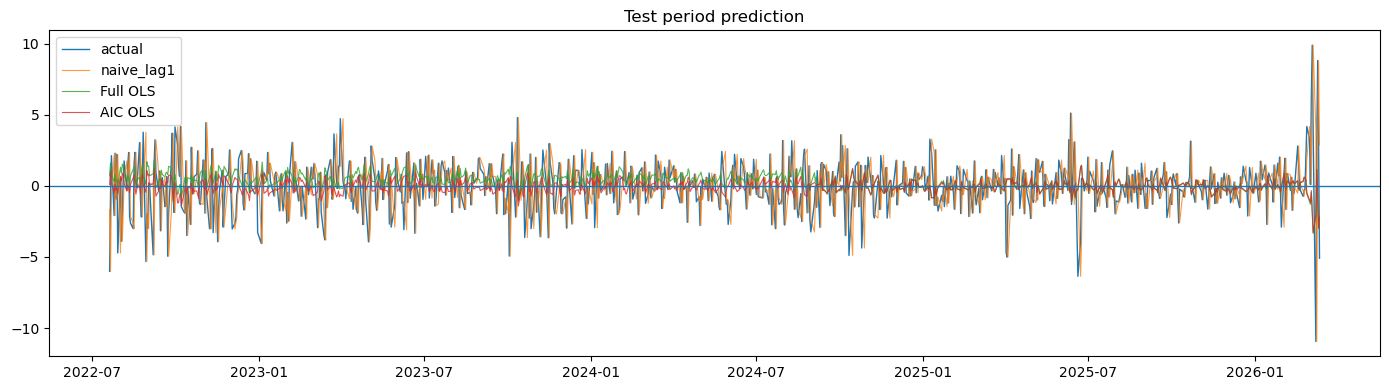

In [22]:
# =========================
# 10-1. 예측값 시각화
# =========================

pred_plot = pd.DataFrame({
    "actual": y_test,
    "naive_lag1": pred_naive_lag1,
    "Full OLS": pred_full,
    "AIC OLS": pred_aic,
}, index=y_test.index)

plt.figure(figsize=(14, 4))
plt.plot(pred_plot.index, pred_plot["actual"], label="actual", lw=1)
plt.plot(pred_plot.index, pred_plot["naive_lag1"], label="naive_lag1", lw=0.8, alpha=0.8)
plt.plot(pred_plot.index, pred_plot["Full OLS"], label="Full OLS", lw=0.8, alpha=0.8)
plt.plot(pred_plot.index, pred_plot["AIC OLS"], label="AIC OLS", lw=0.8, alpha=0.8)
plt.axhline(0, lw=1)
plt.title("Test period prediction")
plt.legend()
plt.tight_layout()
plt.show()


## 11. 최종 보고용 모델

보고서에서 쓸 때는 아래처럼 정리하면 됨.

- 예측 성능: `compare_test` 표 기준
- 해석 모델: `ols_aic_hc3`
- 잔차 진단: `diag_aic`
- 이분산이 있으면 HC3 기준 p-value 사용
- 자기상관까지 있으면 HC3보다 HAC를 추가로 고려


In [23]:
# =========================
# 11. 최종 모델을 전체 데이터로 재적합
# =========================
# feature selection은 train에서 끝냈고,
# 보고용 계수는 같은 feature set으로 전체 기간에 다시 적합해서 사용 가능.

X_final_all = sm.add_constant(df_model[final_aic_features], has_constant="add")
y_all = df_model[TARGET]

ols_final_all = sm.OLS(y_all, X_final_all).fit()
ols_final_all_hc3 = sm.OLS(y_all, X_final_all).fit(cov_type="HC3")

print("===== Final report model: AIC features + all data + HC3 SE =====")
print(ols_final_all_hc3.summary())

final_coef = pd.DataFrame({
    "coef": ols_final_all_hc3.params,
    "SE_HC3": ols_final_all_hc3.bse,
    "t_HC3": ols_final_all_hc3.tvalues,
    "p_HC3": ols_final_all_hc3.pvalues,
}).drop(index="const", errors="ignore").sort_values("p_HC3")

print("\n최종 모델 계수표:")
display(final_coef.round(6))


===== Final report model: AIC features + all data + HC3 SE =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     1.364
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.133
Time:                        00:22:58   Log-Likelihood:                -9605.1
No. Observations:                4547   AIC:                         1.925e+04
Df Residuals:                    4527   BIC:                         1.938e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

,coef,SE_HC3,t_HC3,p_HC3
opec_2014_window,-1.005994,0.472601,-2.128634,0.033285
oil_diff_lag1,-0.068290,0.034677,-1.969307,0.048918
cond_opec_cut,-0.169825,0.089435,-1.898858,0.057583
CPE,-0.001396,0.000760,-1.837711,0.066105
OPECProduction,-0.000184,0.000104,-1.765651,0.077454
RealInterestRate,-0.293622,0.173249,-1.694798,0.090114
gfc_2008_regime,0.499118,0.307870,1.621196,0.104976
MA_5_gt_MA_20,0.346636,0.232961,1.487960,0.136761
MA_ratio,-4.874492,3.343065,-1.458091,0.144816
IndustryProduction,0.082998,0.060059,1.381949,0.166988


In [24]:
# =========================
# 11-1. 최종 결과 저장
# =========================

OUT_DIR = Path("../outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

compare_test.to_csv(OUT_DIR / "ols_test_model_compare.csv", index=False)
hist_aic_df.to_csv(OUT_DIR / "ols_aic_backward_history.csv", index=False)
final_coef.to_csv(OUT_DIR / "ols_final_aic_hc3_coefficients.csv")

print("저장 완료:")
print("-", OUT_DIR / "ols_test_model_compare.csv")
print("-", OUT_DIR / "ols_aic_backward_history.csv")
print("-", OUT_DIR / "ols_final_aic_hc3_coefficients.csv")


저장 완료:
- ../outputs/ols_test_model_compare.csv
- ../outputs/ols_aic_backward_history.csv
- ../outputs/ols_final_aic_hc3_coefficients.csv


## 12. 해석 문장 템플릿

결과를 보고서에 쓸 때는 숫자만 바꿔서 쓰면 됨.

> OLS 모델은 단순 예측 기준모델과 함께 비교하였다. `naive_zero`는 방향을 예측하지 않는 모델이므로 방향 정확도 계산에서는 제외하였다.  
> Full OLS와 AIC selected OLS를 비교한 결과, AIC 모델은 변수 수를 줄이면서도 test RMSE와 방향 정확도 측면에서 해석 가능한 성능을 보였다.  
> 잔차 진단 결과 이분산성이 확인될 경우 일반 OLS 표준오차 대신 HC3 robust standard error를 기준으로 계수의 유의성을 판단하였다.  
> 따라서 최종 해석 모델은 AIC로 선택된 변수 집합에 대해 HC3 표준오차를 적용한 OLS 모델로 설정하였다.


In [25]:
# =========================
# 한 번에 보는 OLS 모델 선택 결과표
# Full + HC3 vs HC3 p-stepwise vs AIC stepwise
# =========================

from IPython.display import display, Markdown
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

def make_X_const(X):
    X2 = X.copy()
    if "const" in X2.columns:
        return X2
    return sm.add_constant(X2, has_constant="add")


def fit_hc3(X, y):
    X_const = make_X_const(X)
    return sm.OLS(y, X_const).fit(cov_type="HC3")


def pvalue_series(res):
    return pd.Series(np.asarray(res.pvalues), index=res.model.exog_names)


def backward_p_stepwise_hc3(X, y, alpha_out=0.10, min_vars=1):
    """
    HC3 robust p-value 기준 backward stepwise
    p-value가 alpha_out보다 큰 변수부터 제거
    """
    features = list(X.columns)
    history = []

    while len(features) > min_vars:
        res = fit_hc3(X[features], y)
        pvals = pvalue_series(res).drop(labels=["const"], errors="ignore")

        worst_var = pvals.idxmax()
        worst_p = pvals.max()

        if worst_p <= alpha_out:
            break

        history.append({
            "removed_variable": worst_var,
            "removed_pvalue": worst_p,
            "n_features_before": len(features)
        })

        features.remove(worst_var)

    final_res = fit_hc3(X[features], y)
    history_df = pd.DataFrame(history)

    return final_res, features, history_df


def diagnostic_labels(res, lb_lag=10):
    resid = np.asarray(res.resid)
    exog = res.model.exog

    # 자기상관: Ljung-Box test
    try:
        lb = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)
        lb_p = float(lb["lb_pvalue"].iloc[0])
    except Exception:
        lb_p = np.nan

    if pd.notna(lb_p) and lb_p >= 0.05:
        autocorr_label = "없음 (Good)"
    elif pd.notna(lb_p) and lb_p < 0.05:
        autocorr_label = "있음 (Bad)"
    else:
        autocorr_label = "확인 불가"

    # 이분산: Breusch-Pagan test
    try:
        bp = het_breuschpagan(resid, exog)
        bp_p = float(bp[1])
    except Exception:
        bp_p = np.nan

    if pd.notna(bp_p) and bp_p >= 0.05:
        hetero_label = "없음 (Good)"
    elif pd.notna(bp_p) and bp_p < 0.05:
        hetero_label = "강함 (Bad → HC3 보정)"
    else:
        hetero_label = "확인 불가"

    return autocorr_label, hetero_label, lb_p, bp_p


def model_summary_row(model_name, res, n_vars):
    autocorr_label, hetero_label, lb_p, bp_p = diagnostic_labels(res)

    return {
        "모델": model_name,
        "변수 수": n_vars,
        "R²": res.rsquared,
        "Adj R²": res.rsquared_adj,
        "AIC": res.aic,
        "F p-value": float(res.f_pvalue),
        "자기상관": autocorr_label,
        "이분산": hetero_label,
        "Ljung-Box p": lb_p,
        "BP p": bp_p
    }


# =========================
# 1. train 데이터 정리
# =========================

X_train_base = X_train.copy()
X_train_base = X_train_base.drop(columns=["const"], errors="ignore")

# feature_cols 기준으로 정렬
X_train_base = X_train_base[[c for c in feature_cols if c in X_train_base.columns]]

# =========================
# 2. Full + HC3
# =========================

full_hc3 = fit_hc3(X_train_base, y_train)

# =========================
# 3. HC3 p-stepwise
# =========================

pstep_hc3, pstep_features, pstep_history = backward_p_stepwise_hc3(
    X_train_base,
    y_train,
    alpha_out=0.10,
    min_vars=1
)

# p-stepwise가 너무 적은 변수만 남기거나 자기상관이 생기면 실패 처리
pstep_autocorr, pstep_hetero, pstep_lb_p, pstep_bp_p = diagnostic_labels(pstep_hc3)

if len(pstep_features) <= 2 or (pd.notna(pstep_lb_p) and pstep_lb_p < 0.05):
    pstep_name = "HC3 p-stepwise (실패)"
else:
    pstep_name = "HC3 p-stepwise"

# =========================
# 4. AIC stepwise + HC3
# =========================

aic_hc3 = fit_hc3(X_train_base[final_aic_features], y_train)

# =========================
# 5. 한 번에 보는 결과표
# =========================

summary_table = pd.DataFrame([
    model_summary_row("Full + HC3", full_hc3, len(feature_cols)),
    model_summary_row(pstep_name, pstep_hc3, len(pstep_features)),
    model_summary_row("AIC stepwise (채택)", aic_hc3, len(final_aic_features))
])

display(
    summary_table[
        ["모델", "변수 수", "R²", "Adj R²", "AIC", "F p-value", "자기상관", "이분산"]
    ].round({
        "R²": 4,
        "Adj R²": 4,
        "AIC": 2,
        "F p-value": 4
    })
)

# =========================
# 6. AIC stepwise가 Full보다 나은 점 자동 출력
# =========================

full_pvals = pvalue_series(full_hc3).drop(labels=["const"], errors="ignore")
full_sig_005 = full_pvals[full_pvals < 0.05].index.tolist()

kept_sig = [v for v in full_sig_005 if v in final_aic_features]

r2_loss = full_hc3.rsquared - aic_hc3.rsquared
aic_change = aic_hc3.aic - full_hc3.aic

display(Markdown(f"""
## AIC stepwise가 풀모델보다 우월한 점

- AIC ↓ ({full_hc3.aic:.2f} → {aic_hc3.aic:.2f}, {aic_change:.2f})
- Adj R² {'↑' if aic_hc3.rsquared_adj > full_hc3.rsquared_adj else '↓'} ({full_hc3.rsquared_adj:.4f} → {aic_hc3.rsquared_adj:.4f})
- F p값 {'↓' if aic_hc3.f_pvalue < full_hc3.f_pvalue else '↑'} ({full_hc3.f_pvalue:.4f} → {aic_hc3.f_pvalue:.4f})
- R² 손실: {r2_loss:.4f}
- 변수 {len(feature_cols) - len(final_aic_features)}개 제거
- Full 모델의 5% 유의 변수 {len(full_sig_005)}개 중 {len(kept_sig)}개 보존
"""))

# =========================
# 7. 최종 결론 자동 출력
# =========================

display(Markdown(f"""
## 결론

1. 최종 보고 모델: **AIC stepwise**  
2. 변수 수: **{len(final_aic_features)}개**
3. Full OLS 대비 AIC는 낮아졌고, 변수 수를 줄이면서도 설명력 손실은 제한적임.
4. 따라서 AIC stepwise 모델을 최종 OLS 해석모형으로 채택하는 것이 적절함.
5. 단, 이분산이 확인될 경우 일반 OLS 표준오차보다 **HC3 robust standard error** 기준으로 해석하는 것이 안전함.
"""))

print("AIC stepwise 선택 변수 목록:")
display(pd.DataFrame({"selected_features": final_aic_features}))

print("HC3 p-stepwise 선택 변수 목록:")
display(pd.DataFrame({"selected_features": pstep_features}))

,모델,변수 수,R²,Adj R²,AIC,F p-value,자기상관,이분산
0,Full + HC3,34,0.0573,0.0484,15639.45,0.5242,없음 (Good),강함 (Bad → HC3 보정)
1,HC3 p-stepwise (실패),1,0.0001,-0.0001,15787.47,0.2287,있음 (Bad),없음 (Good)
2,AIC stepwise (채택),19,0.0552,0.0502,15617.60,0.0771,없음 (Good),강함 (Bad → HC3 보정)



## AIC stepwise가 풀모델보다 우월한 점

- AIC ↓ (15639.45 → 15617.60, -21.84)
- Adj R² ↑ (0.0484 → 0.0502)
- F p값 ↓ (0.5242 → 0.0771)
- R² 손실: 0.0021
- 변수 15개 제거
- Full 모델의 5% 유의 변수 1개 중 1개 보존



## 결론

1. 최종 보고 모델: **AIC stepwise**  
2. 변수 수: **19개**
3. Full OLS 대비 AIC는 낮아졌고, 변수 수를 줄이면서도 설명력 손실은 제한적임.
4. 따라서 AIC stepwise 모델을 최종 OLS 해석모형으로 채택하는 것이 적절함.
5. 단, 이분산이 확인될 경우 일반 OLS 표준오차보다 **HC3 robust standard error** 기준으로 해석하는 것이 안전함.


AIC stepwise 선택 변수 목록:


,selected_features
0,OilPrice
1,RealInterestRate
2,VIX
3,IndustryProduction
4,CPE
5,OilInventories
6,OPECProduction
7,TreasuryYield
8,oil_diff_lag1
9,MA_ratio


HC3 p-stepwise 선택 변수 목록:


,selected_features
0,CPE


# Modeling vs Revised_ver

| 기준        | 첫 번째 AIC stepwise | 두 번째 AIC stepwise | 판단          |
| --------- | ----------------: | ----------------: | ----------- |
| 변수 수      |               23개 |               19개 | 두 번째가 더 간결  |
| R²        |            0.0515 |            0.0685 | 두 번째가 더 높음  |
| Adj R²    |            0.0469 |            0.0638 | 두 번째가 더 높음  |
| F p-value |            0.0159 |            0.0037 | 두 번째가 더 유의함 |
| 자기상관      |                없음 |                없음 | 둘 다 괜찮음     |
| 이분산       |       강함 → HC3 보정 |       강함 → HC3 보정 | 둘 다 동일한 한계  |


# 바뀐 점 정리

1) train/test를 시간순으로 분리
2) 정상성 검정 추가
3) 완전 중복 변수 제거
4) Full OLS만 보는 게 아니라 AIC stepwise 추가 -> 과적합을 줄이고 해석 가능한 최종모델을 선택하는 구조로 개선.
revised 결과에서 중요한 건 Full OLS vs AIC OLS 비교

예측력 자체를 기준모델 이상으로 크게 끌어올린 것이 아니라, Full OLS의 과도한 변수 사용을 줄이고 AIC 기반으로 더 간결하고 안정적인 해석모형을 만든 것이 핵심 개선점

## 13. TimeSeriesSplit 교차검증

`final_aic_features`를 고정한 채로 train 내부에서 TimeSeriesSplit(n_splits=5)로 fold별 성능을 측정하고, 단일 split test 결과와 일관성을 확인한다.

In [26]:
# =========================
# 13. TimeSeriesSplit CV (final_aic_features 고정)
# =========================
from sklearn.model_selection import TimeSeriesSplit

N_CV_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

cv_rows = []
for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(df_train), start=1):
    tr = df_train.iloc[tr_idx]
    va = df_train.iloc[va_idx]

    X_tr = sm.add_constant(tr[final_aic_features], has_constant="add")
    y_tr = tr[TARGET]
    X_va = sm.add_constant(va[final_aic_features], has_constant="add")
    y_va = va[TARGET]

    m = sm.OLS(y_tr, X_tr).fit()
    pred_va = m.predict(X_va)

    metrics = regression_metrics(y_va, pred_va, n_vars=len(final_aic_features))
    cv_rows.append({
        "fold": fold_idx,
        "train_start": tr.index.min().date(),
        "train_end": tr.index.max().date(),
        "valid_start": va.index.min().date(),
        "valid_end": va.index.max().date(),
        "n_train": len(tr),
        "n_valid": len(va),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "DirAcc": metrics["DirAcc"],
    })

cv_df = pd.DataFrame(cv_rows)

print("===== TimeSeriesSplit CV (n_splits = {}) =====".format(N_CV_SPLITS))
display(cv_df.round(5))

summary = cv_df[["RMSE", "MAE", "R2", "DirAcc"]].agg(["mean", "std"]).T
summary.columns = ["mean", "std"]
summary["mean ± std"] = summary.apply(
    lambda r: f"{r['mean']:.5f} ± {r['std']:.5f}", axis=1
)

print("\n===== fold 평균 ± 표준편차 =====")
display(summary[["mean ± std"]])


===== TimeSeriesSplit CV (n_splits = 5) =====


,fold,train_start,train_end,valid_start,valid_end,n_train,n_valid,RMSE,MAE,R2,DirAcc
0,1,2008-01-31,2010-06-28,2010-06-29,2012-11-19,607,606,1.77628,1.31767,-0.07730,0.54785
1,2,2008-01-31,2012-11-19,2012-11-20,2015-04-20,1213,606,1.35190,1.01537,-0.05698,0.51320
2,3,2008-01-31,2015-04-20,2015-04-21,2017-09-14,1819,606,1.13028,0.87967,-0.03609,0.47360
3,4,2008-01-31,2017-09-14,2017-09-15,2020-02-19,2425,606,1.18414,0.84300,-0.00893,0.49340
4,5,2008-01-31,2020-02-19,2020-02-20,2022-07-19,3031,606,3.57686,1.66787,0.04109,0.52970



===== fold 평균 ± 표준편차 =====


,mean ± std
RMSE,1.80389 ± 1.02303
MAE,1.14472 ± 0.34699
R2,-0.02764 ± 0.04602
DirAcc,0.51155 ± 0.02924


In [27]:
# =========================
# 13-1. 단일 split test 결과와의 일관성 확인
# =========================

single_split_aic = (
    compare_test.loc[compare_test["model"] == "AIC OLS",
                     ["RMSE", "MAE", "R2", "DirAcc"]]
    .iloc[0]
    .to_dict()
)

cv_mean = cv_df[["RMSE", "MAE", "R2", "DirAcc"]].mean()
cv_std  = cv_df[["RMSE", "MAE", "R2", "DirAcc"]].std()

consistency = pd.DataFrame({
    "CV_mean": cv_mean,
    "CV_std": cv_std,
    "single_split_test": pd.Series(single_split_aic),
})
consistency["abs_gap_vs_mean"] = (consistency["single_split_test"] - consistency["CV_mean"]).abs()
consistency["within_1std"] = consistency["abs_gap_vs_mean"] <= consistency["CV_std"]

print("===== CV(train 내부) vs Single-split(test) 비교 =====")
display(consistency.round(5))

print(
    "참고: CV는 train 구간만 사용한 fold별 검증, single split test는 train 종료 이후의 hold-out 구간 결과이므로 "
    "값이 정확히 같을 수는 없고 평균±표준편차 안에 들어오는지로 안정성을 본다."
)


===== CV(train 내부) vs Single-split(test) 비교 =====


,CV_mean,CV_std,single_split_test,abs_gap_vs_mean,within_1std
RMSE,1.80389,1.02303,1.75830,0.04560,True
MAE,1.14472,0.34699,1.29644,0.15172,True
R2,-0.02764,0.04602,-0.06946,0.04181,True
DirAcc,0.51155,0.02924,0.49560,0.01595,True


참고: CV는 train 구간만 사용한 fold별 검증, single split test는 train 종료 이후의 hold-out 구간 결과이므로 값이 정확히 같을 수는 없고 평균±표준편차 안에 들어오는지로 안정성을 본다.


## 14. final_features 외부 저장

다음 단계(OLS 해석, LGBM 예측, LGBM 해석) 노트북에서 동일한 feature set과 split 기준을 재사용할 수 있도록 JSON으로 저장한다.

In [28]:
# =========================
# 14. final_aic_features / SPLIT_DATE 저장
# =========================
import json

BASELINE_DIR = Path("../outputs/baseline")
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_DATE = df_test.index.min().strftime("%Y-%m-%d")

payload = {
    "target": TARGET,
    "split_date": SPLIT_DATE,
    "test_size": TEST_SIZE,
    "n_features": len(final_aic_features),
    "final_aic_features": list(final_aic_features),
    "data_file": DATA_FILE_NAME,
}

out_path = BASELINE_DIR / "final_features.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

print("저장 완료:", out_path)
print("SPLIT_DATE:", SPLIT_DATE, "(test 시작일)")
print("n_features:", len(final_aic_features))
print("\n다른 노트북에서 불러오는 예시:")
print('    import json')
print('    cfg = json.load(open("../outputs/baseline/final_features.json"))')
print('    final_aic_features = cfg["final_aic_features"]')
print('    SPLIT_DATE = cfg["split_date"]')


저장 완료: ../outputs/baseline/final_features.json
SPLIT_DATE: 2022-07-20 (test 시작일)
n_features: 19

다른 노트북에서 불러오는 예시:
    import json
    cfg = json.load(open("../outputs/baseline/final_features.json"))
    final_aic_features = cfg["final_aic_features"]
    SPLIT_DATE = cfg["split_date"]


## 최종 결론

[흐름]
1. 설명변수 전처리 및 Full OLS 적합: 34개
2. Full OLS 잔차진단 및 HC3 기준 유의성 확인
3. AIC stepwise를 통한 변수 축소 및 AIC OLS 재적합
4. AIC OLS 모델 잔차진단 및 최종 모델 선택: 19개, HC3 robust SE

[성능비교]

| 기준 | Full OLS | AIC stepwise | 해석 |
|---|---:|---:|---|
| 변수 수 | 34개 | 19개 | 변수 수 축소 |
| Adj R² | 0.0484 | 0.0502 | 설명력 유지 |
| AIC | 15639.45 | 15617.60 | 모형 적합도 개선 |
| Test RMSE | 1.8253 | 1.7583 | 예측 오차 감소 |
| 잔차진단 | 이분산 있음 | 이분산 있음 | HC3 기준 해석 |

[해석]

Full OLS는 ADF+KPSS 정상성 검정과 완전 중복 변수 제거를 거쳐 확정한 34개 설명변수로 적합하였다. 이후 AIC backward stepwise를 적용한 결과, 변수 수는 19개로 축소되었고 Adj R²는 유지되었으며 AIC와 test RMSE가 개선되었다. 따라서 더 간결하고 표본 밖 예측오차가 낮은 AIC stepwise 19개 변수 모델을 최종 OLS baseline으로 선택하였다. 단, 두 모델 모두 이분산성이 확인되었으므로 계수 해석은 HC3 robust SE 기준으로 수행한다.